# Explore – NRW Mietdaten

Dieses Notebook entspricht der **Explore** Phase des OSEMN-Frameworks.
Der Fokus liegt auf deskriptiver Statistik und der visuellen Exploration der Mietpreise, ohne Hypothesentests oder Modellierung anzuwenden.

Dieses Notebook verwendet ausschließlich den bereinigten Datensatz aus
data/processed/nrw_clean.csv und beantwortet die Forschungsfragen explorativ.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/nrw_clean.csv")
df.shape


C:\Users\User\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


(62822, 9)

In [2]:
df.head()


,regio2,baseRent,totalRent,livingSpace,noRooms,balcony,hasKitchen,yearConstructed,price_per_sqm
0,Dortmund,595.0,840.00,86.00,4.0,False,False,1965.0,6.918605
1,Gelsenkirchen,300.0,NaN,60.00,2.5,False,False,1953.0,5.000000
2,Hamm,950.0,1150.00,123.44,4.0,False,False,1951.0,7.696047
3,Dortmund,972.6,1320.65,87.00,3.0,True,False,2018.0,11.179310
4,Duisburg,329.0,NaN,65.00,2.5,True,False,1914.0,5.061538


In [3]:
df.isna().sum()


regio2                 0
baseRent               0
totalRent          12091
livingSpace            0
noRooms                0
balcony                0
hasKitchen             0
yearConstructed    12037
price_per_sqm          0
dtype: int64

## Forschungsfrage 1 (Stadtvergleich)

Top-10 Städte nach Anzahl der Inserate

In [5]:
top_cities = (
    df["regio2"]
    .value_counts()
    .head(10)
    .index
)

top_cities


Index(['Essen', 'Düsseldorf', 'Duisburg', 'Dortmund', 'Gelsenkirchen',
       'Recklinghausen_Kreis', 'Köln', 'Wuppertal', 'Bochum', 'Aachen'],
      dtype='object', name='regio2')

### Tabelle: Median €/m² + Anzahl:

In [6]:
rq1_table = (
    df[df["regio2"].isin(top_cities)]
    .groupby("regio2")
    .agg(
        median_eur_per_sqm=("price_per_sqm", "median"),
        n_offers=("price_per_sqm", "size")
    )
    .sort_values("median_eur_per_sqm", ascending=False)
)

rq1_table


,median_eur_per_sqm,n_offers
regio2,,
Köln,12.567444,2702
Düsseldorf,11.988548,3708
Aachen,9.420290,1889
Dortmund,7.707160,3135
Essen,7.222368,4350
Bochum,7.142857,2007
Wuppertal,6.500000,2376
Recklinghausen_Kreis,6.168831,2754
Duisburg,6.020558,3519


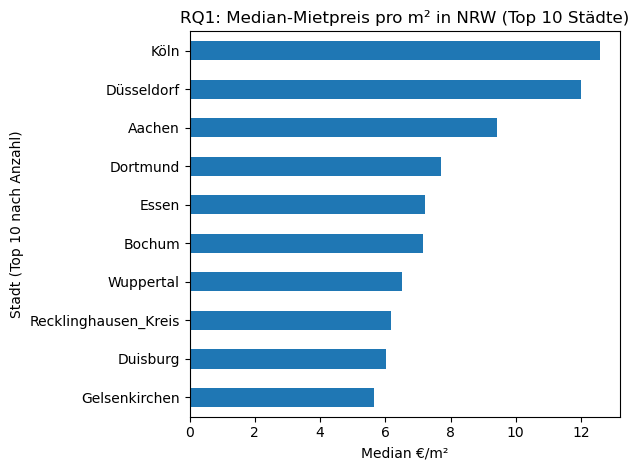

(True,
 WindowsPath('C:/Users/User/Desktop/DATA INFORMATION SCIENCE/DIS08/dis08-miete-nrw/docs/rq1_median_mietpreis_top10_staedte.png'))

In [16]:
rq1_table["median_eur_per_sqm"].sort_values().plot(kind="barh")
plt.xlabel("Median €/m²")
plt.ylabel("Stadt (Top 10 nach Anzahl)")
plt.title("RQ1: Median-Mietpreis pro m² in NRW (Top 10 Städte)")
plt.tight_layout()

from pathlib import Path
import matplotlib.pyplot as plt

docs_path = Path("../docs")
docs_path.mkdir(parents=True, exist_ok=True)

file_path = docs_path / "rq1_median_mietpreis_top10_staedte.png"

plt.savefig(file_path, dpi=300, bbox_inches="tight")
plt.show()

file_path.exists(), file_path.resolve()


- Die Median-Mietpreise pro m² unterscheiden sich deutlich zwischen den Top-Städten in NRW.

- Städte wie Köln und Düsseldorf liegen typischerweise höher als viele Ruhrgebietsstädte (z. B. Duisburg/Gelsenkirchen).

- Das deutet auf klare regionale Preisunterschiede und unterschiedliche Nachfragesituationen hin.

## Forschungsfrage 2 (Wohnungsgröße)

In [8]:
small = df[df["livingSpace"] < 50]
medium = df[(df["livingSpace"] >= 50) & (df["livingSpace"] <= 80)]
large = df[df["livingSpace"] > 80]


In [9]:
rq2_table = pd.DataFrame({
    "group": ["<50", "50-80", ">80"],
    "median_eur_per_sqm": [
        small["price_per_sqm"].median(),
        medium["price_per_sqm"].median(),
        large["price_per_sqm"].median()
    ],
    "n_offers": [len(small), len(medium), len(large)]
})

rq2_table


,group,median_eur_per_sqm,n_offers
0,<50,8.238929,9193
1,50-80,6.686974,33824
2,>80,7.960631,19805


Boxplot

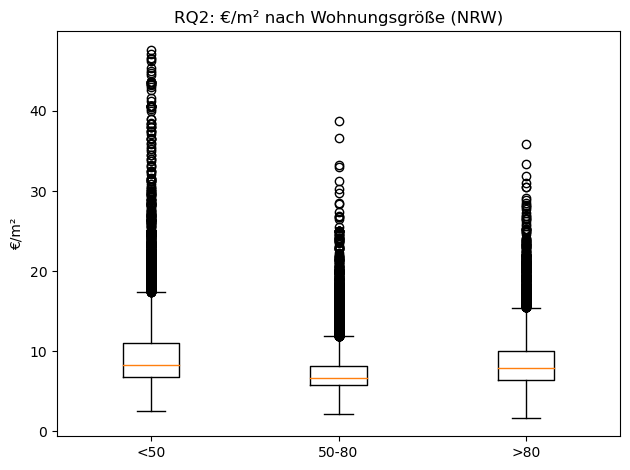

(True,
 WindowsPath('C:/Users/User/Desktop/DATA INFORMATION SCIENCE/DIS08/dis08-miete-nrw/docs/rq2_boxplot_mietpreis_nach_wohnungsgröße.png'))

In [17]:
plt.boxplot(
    [small["price_per_sqm"], medium["price_per_sqm"], large["price_per_sqm"]],
    labels=["<50", "50-80", ">80"]
)
plt.ylabel("€/m²")
plt.title("RQ2: €/m² nach Wohnungsgröße (NRW)")
plt.tight_layout()

from pathlib import Path
import matplotlib.pyplot as plt

docs_path = Path("../docs")
docs_path.mkdir(parents=True, exist_ok=True)

file_path = docs_path / "rq2_boxplot_mietpreis_nach_wohnungsgröße.png"

plt.savefig(file_path, dpi=300, bbox_inches="tight")
plt.show()

file_path.exists(), file_path.resolve()


- In der Regel zeigen kleinere Wohnungen (<50 m²) höhere €/m²-Medianwerte als mittlere Wohnungen.

- Der Boxplot macht außerdem sichtbar, dass es in allen Gruppen Ausreißer gibt.

- Das ist zunächst eine explorative Beobachtung; ein formaler Test folgt erst im Model/Hypothesis-Notebook.

In [11]:
df.isna().sum()


regio2                 0
baseRent               0
totalRent          12091
livingSpace            0
noRooms                0
balcony                0
hasKitchen             0
yearConstructed    12037
price_per_sqm          0
dtype: int64